# Credit Card Behavior Score - EDA
Goal: Behaviour Score = predict probability an existing (open, not-past-due) Credit Card account defaults going forward, per `instruction.md`.

Dev set (`Dev_data_to_be_shared.csv`) has target `bad_flag` (1 = defaulted). Validation set has no target (scoring set) — final deliverable is `account_number` + predicted probability for validation.

Four documented feature groups (by column prefix):
- `onus_attribute_*` — on-us attributes (e.g. credit limit)
- `transaction_attribute_*` — transaction-level attributes (counts / rupee value by merchant type)
- `bureau_*` (excluding `bureau_enquiry_*`) — bureau tradeline-level attributes (product holdings, historical delinquencies)
- `bureau_enquiry_*` — bureau enquiry-level attributes (e.g. PL enquiries in last 3 months)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

DEV_PATH = 'Dev_data_to_be_shared.csv'
VAL_PATH = 'validation_data_to_be_shared.csv'

In [2]:
dev = pd.read_csv(DEV_PATH)
val = pd.read_csv(VAL_PATH)
print('dev shape:', dev.shape)
print('val shape:', val.shape)

dev shape: (96806, 1216)
val shape: (41792, 1215)


## Basic structure

In [3]:
dev.head()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,transaction_attribute_8,transaction_attribute_9,transaction_attribute_10,transaction_attribute_11,transaction_attribute_12,transaction_attribute_13,transaction_attribute_14,transaction_attribute_15,transaction_attribute_16,transaction_attribute_17,transaction_attribute_18,transaction_attribute_19,transaction_attribute_20,transaction_attribute_21,transaction_attribute_22,transaction_attribute_23,transaction_attribute_24,transaction_attribute_25,transaction_attribute_26,transaction_attribute_27,transaction_attribute_28,transaction_attribute_29,transaction_attribute_30,transaction_attribute_31,transaction_attribute_32,transaction_attribute_33,transaction_attribute_34,transaction_attribute_35,transaction_attribute_36,transaction_attribute_37,transaction_attribute_38,transaction_attribute_39,transaction_attribute_40,transaction_attribute_41,transaction_attribute_42,transaction_attribute_43,transaction_attribute_44,transaction_attribute_45,transaction_attribute_46,transaction_attribute_47,...,bureau_enquiry_7,bureau_enquiry_8,bureau_enquiry_9,bureau_enquiry_10,bureau_enquiry_11,bureau_enquiry_12,bureau_enquiry_13,bureau_enquiry_14,bureau_enquiry_15,bureau_enquiry_16,bureau_enquiry_17,bureau_enquiry_18,bureau_enquiry_19,bureau_enquiry_20,bureau_enquiry_21,bureau_enquiry_22,bureau_enquiry_23,bureau_enquiry_24,bureau_enquiry_25,bureau_enquiry_26,bureau_enquiry_27,bureau_enquiry_28,bureau_enquiry_29,bureau_enquiry_30,bureau_enquiry_31,bureau_enquiry_32,bureau_enquiry_33,bureau_enquiry_34,bureau_enquiry_35,bureau_enquiry_36,bureau_enquiry_37,bureau_enquiry_38,bureau_enquiry_39,bureau_enquiry_40,bureau_enquiry_41,bureau_enquiry_42,bureau_enquiry_43,bureau_enquiry_44,bureau_enquiry_45,bureau_enquiry_46,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2899.0,2.0,1629.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,564.130005,2.0,414.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,2.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,5.0,2.0,3.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,6.0,2.0,4.0,0.0,1.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6454.800049,2.0,3629.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,11.0,0.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,11.0,0.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10999.0,1.0,10999.0,0.0,0.0,...,0.0,0.0,0.0,2.0,6.0,0.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,12.0,0.0,12.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,24.0,0.0,24.0,0.0,2.0,0.0,0.0,0.0,0.0,21.0,38.0,0.0,38.0,0.0,6.0,0.0,0.0,0.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.

In [4]:
print('dtype counts:')
print(dev.dtypes.value_counts())
print()
print('memory usage (MB):', dev.memory_usage(deep=True).sum() / 1e6)
print('duplicate account_number in dev:', dev['account_number'].duplicated().sum())
print('duplicate account_number in val:', val['account_number'].duplicated().sum())
print('account overlap dev/val:', len(set(dev['account_number']) & set(val['account_number'])))

dtype counts:
float64    1189
int64        27
Name: count, dtype: int64

memory usage (MB): 941.7289
duplicate account_number in dev: 0
duplicate account_number in val: 0
account overlap dev/val: 0


## Target variable: bad_flag

bad_flag
0    95434
1     1372
Name: count, dtype: int64
bad_flag
0    0.985827
1    0.014173
Name: proportion, dtype: float64


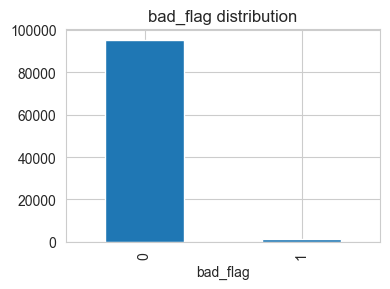

In [5]:
print(dev['bad_flag'].value_counts(dropna=False))
print(dev['bad_flag'].value_counts(normalize=True, dropna=False))

fig, ax = plt.subplots(figsize=(4,3))
dev['bad_flag'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('bad_flag distribution')
plt.tight_layout()
plt.show()

## Missing values

In [6]:
missing = dev.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print('columns with missing values:', len(missing))
print('top 20 by missing %:')
print((missing.head(20) * 100).round(2))

columns with missing values: 1185
top 20 by missing %:
bureau_447           100.00
bureau_436           100.00
bureau_449            94.12
bureau_148            93.55
bureau_448            90.03
onus_attribute_44     88.01
onus_attribute_43     88.01
onus_attribute_48     88.01
onus_attribute_47     88.01
onus_attribute_45     88.01
onus_attribute_46     88.01
bureau_444            87.74
bureau_438            85.54
bureau_446            83.38
bureau_435            76.95
bureau_433            76.22
bureau_437            67.46
bureau_451            57.21
bureau_445            53.69
onus_attribute_7      46.44
dtype: float64


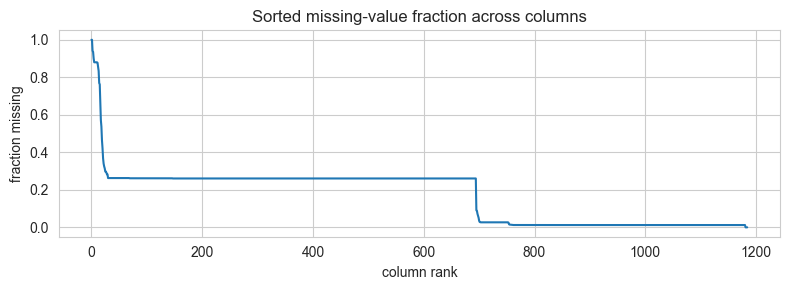

In [7]:
fig, ax = plt.subplots(figsize=(8,3))
missing.reset_index(drop=True).plot(ax=ax)
ax.set_title('Sorted missing-value fraction across columns')
ax.set_xlabel('column rank')
ax.set_ylabel('fraction missing')
plt.tight_layout()
plt.show()

## Summary statistics (numeric features)

In [8]:
num_cols = dev.select_dtypes(include=[np.number]).columns.drop(['bad_flag'], errors='ignore')
desc = dev[num_cols].describe().T
desc['skew'] = dev[num_cols].skew()
desc.sort_values('skew', ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max,skew
bureau_441,94062.0,0.403407,36.245278,-4.582061,0.052222,0.243385,0.447838,11114.400000,306.519200
transaction_attribute_222,71575.0,0.000002,0.000527,0.000000,0.000000,0.000000,0.000000,0.141004,267.535044
transaction_attribute_79,71575.0,0.480684,128.599756,0.000000,0.000000,0.000000,0.000000,34404.941410,267.535044
transaction_attribute_183,71575.0,0.000014,0.003738,0.000000,0.000000,0.000000,0.000000,1.000000,267.535044
transaction_attribute_80,71575.0,0.000014,0.003738,0.000000,0.000000,0.000000,0.000000,1.000000,267.535044
transaction_attribute_81,71575.0,0.480684,128.599751,0.000000,0.000000,0.000000,0.000000,34404.940000,267.535044
transaction_attribute_574,71471.0,0.000014,0.003741,0.000000,0.000000,0.000000,0.000000,1.000000,267.314551
transaction_attribute_578,71471.0,0.052796,10.282935,-15.985216,0.000000,0.000000,0.000000,2748.791943,267.262298
transaction_attribute_313,71575.0,1.569460,408.871556,0.000000,0.000000,0.000000,0.000000,109346.710900,267.241232
transaction_attribute_652,71575.0,0.000003,0.000838,0.000000,0.000000,0.000000,0.000000,0.224071,267.185519


## Zero-variance / near-constant columns

In [9]:
nunique = dev[num_cols].nunique()
const_cols = nunique[nunique <= 1].index.tolist()
print('constant columns:', len(const_cols))
print(const_cols[:20])

constant columns: 56
['transaction_attribute_152', 'transaction_attribute_191', 'transaction_attribute_524', 'transaction_attribute_525', 'transaction_attribute_582', 'transaction_attribute_621', 'bureau_4', 'bureau_16', 'bureau_26', 'bureau_38', 'bureau_47', 'bureau_56', 'bureau_70', 'bureau_80', 'bureau_90', 'bureau_100', 'bureau_110', 'bureau_120', 'bureau_131', 'bureau_142']


## Correlation with target

In [10]:
corr_with_target = dev[num_cols].corrwith(dev['bad_flag']).sort_values(key=lambda s: s.abs(), ascending=False)
print('top 20 features by |correlation| with bad_flag:')
print(corr_with_target.head(20))

C:\Users\phamminhha3006\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\phamminhha3006\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


top 20 features by |correlation| with bad_flag:
onus_attribute_2     0.108491
onus_attribute_17    0.103156
onus_attribute_23    0.100748
onus_attribute_20    0.100672
onus_attribute_26    0.098549
onus_attribute_32    0.096320
onus_attribute_29    0.093453
onus_attribute_33    0.092944
onus_attribute_35    0.090654
onus_attribute_38    0.089201
onus_attribute_39    0.087082
onus_attribute_27    0.087046
onus_attribute_41    0.086742
onus_attribute_46    0.078038
onus_attribute_44    0.075761
bureau_enquiry_13    0.073898
bureau_enquiry_11    0.073243
onus_attribute_37    0.072364
bureau_enquiry_23    0.072162
bureau_enquiry_21    0.072136
dtype: float64


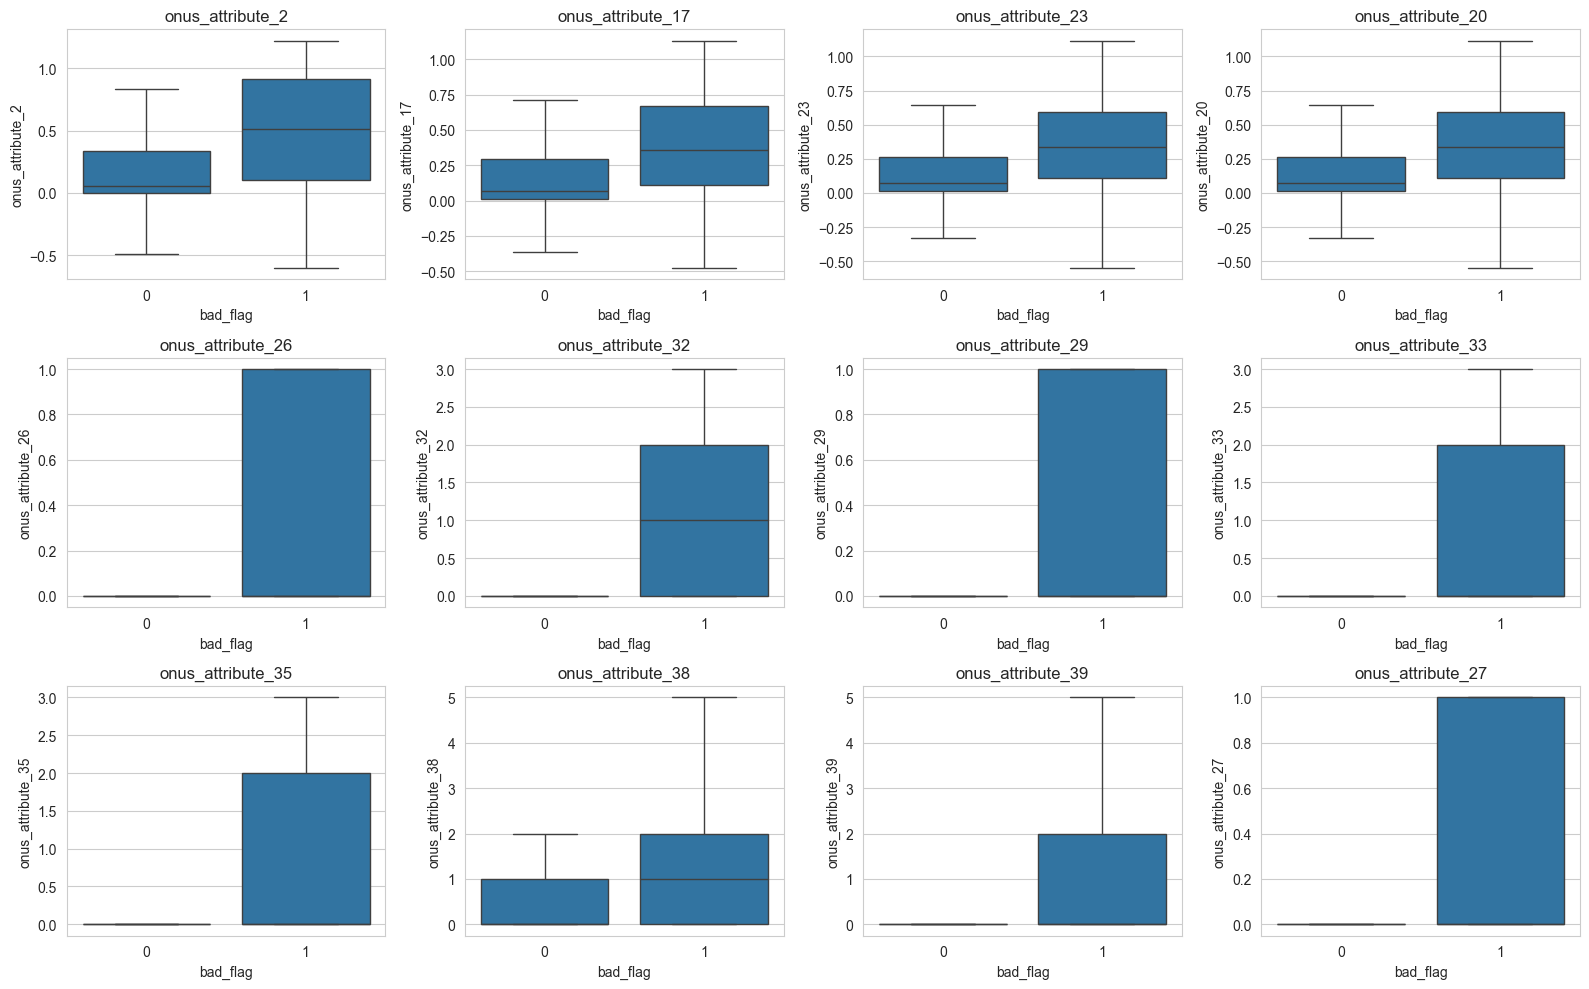

In [11]:
top_feats = corr_with_target.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), top_feats):
    sns.boxplot(x='bad_flag', y=col, data=dev, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Feature-feature correlation (top features by target correlation)

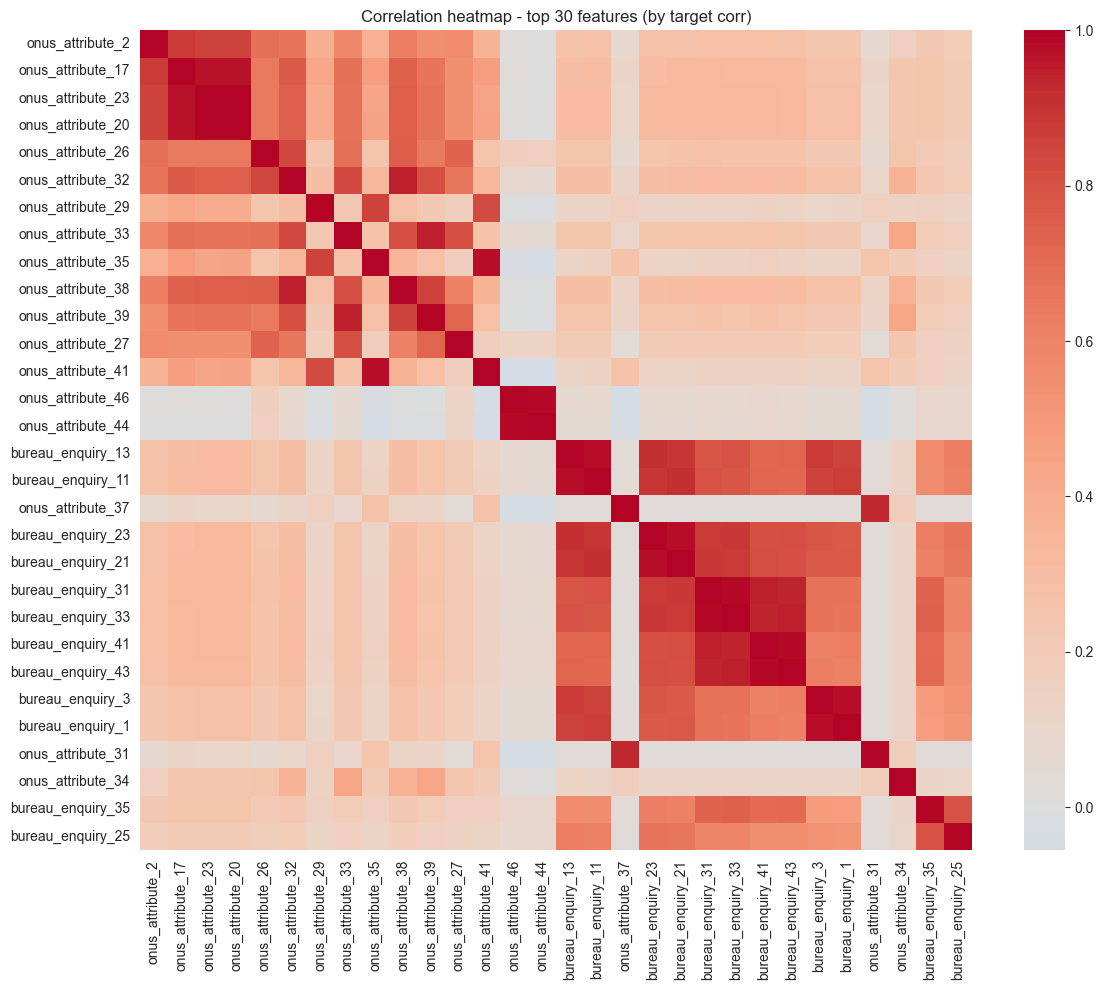

In [12]:
top30 = corr_with_target.head(30).index.tolist()
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(dev[top30].corr(), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap - top 30 features (by target corr)')
plt.tight_layout()
plt.show()

## Dev vs validation distribution drift check (top features)

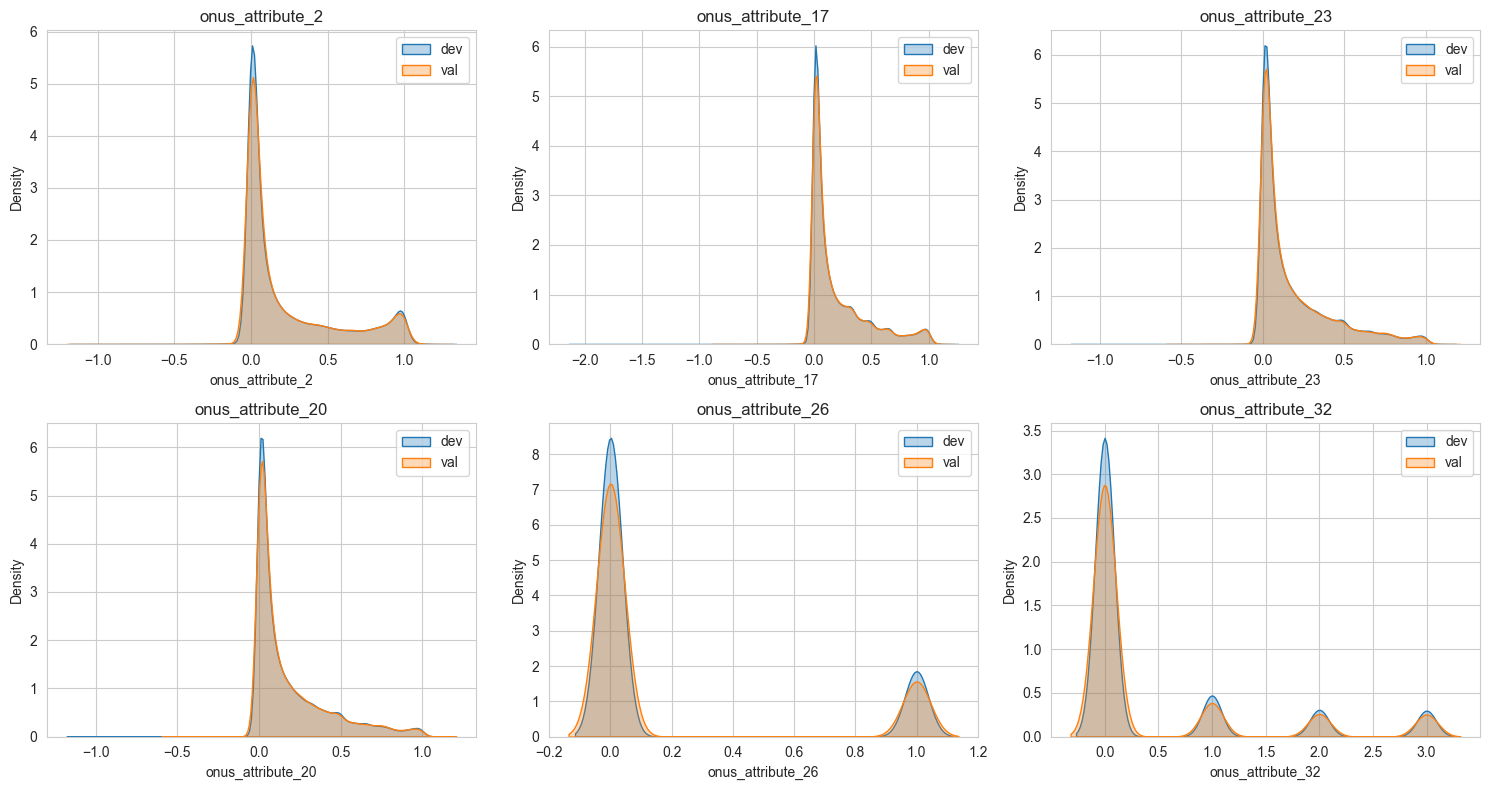

In [13]:
check_feats = corr_with_target.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), check_feats):
    sns.kdeplot(dev[col].dropna(), ax=ax, label='dev', fill=True, alpha=0.3)
    sns.kdeplot(val[col].dropna(), ax=ax, label='val', fill=True, alpha=0.3)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## Feature groups: onus / transaction / bureau / bureau_enquiry

In [14]:
onus_cols = [c for c in dev.columns if c.startswith('onus_attribute')]
txn_cols = [c for c in dev.columns if c.startswith('transaction_attribute')]
enq_cols = [c for c in dev.columns if c.startswith('bureau_enquiry')]
bureau_cols = [c for c in dev.columns if c.startswith('bureau_') and c not in enq_cols]

groups = {
    'onus_attribute': onus_cols,
    'transaction_attribute': txn_cols,
    'bureau': bureau_cols,
    'bureau_enquiry': enq_cols,
}

assigned = onus_cols + txn_cols + bureau_cols + enq_cols
unassigned = [c for c in dev.columns if c not in assigned + ['account_number', 'bad_flag']]
print('unassigned columns (should be empty):', unassigned)
print()

rows = []
for name, cols in groups.items():
    miss_pct = dev[cols].isna().mean() * 100
    corr_abs = corr_with_target[corr_with_target.index.isin(cols)].abs()
    rows.append({
        'group': name,
        'n_cols': len(cols),
        'mean_missing_pct': miss_pct.mean(),
        'max_missing_pct': miss_pct.max(),
        'mean_abs_corr_with_target': corr_abs.mean(),
        'max_abs_corr_with_target': corr_abs.max(),
        'top_feature': corr_abs.idxmax() if len(corr_abs) else None,
    })
pd.DataFrame(rows).set_index('group').round(4)

unassigned columns (should be empty): []



,n_cols,mean_missing_pct,max_missing_pct,mean_abs_corr_with_target,max_abs_corr_with_target,top_feature
group,,,,,,
onus_attribute,48,16.9583,88.0069,0.0497,0.1085,onus_attribute_2
transaction_attribute,664,26.0873,26.2794,0.0080,0.0634,transaction_attribute_619
bureau,452,3.8717,100.0000,0.0152,0.0621,bureau_439
bureau_enquiry,50,2.6796,2.6796,0.0340,0.0739,bureau_enquiry_13


## Top predictive feature per group

In [15]:
for name, cols in groups.items():
    sub = corr_with_target[corr_with_target.index.isin(cols)].sort_values(key=lambda s: s.abs(), ascending=False)
    print(f'--- {name} (top 5 by |corr| with bad_flag) ---')
    print(sub.head(5))
    print()

--- onus_attribute (top 5 by |corr| with bad_flag) ---
onus_attribute_2     0.108491
onus_attribute_17    0.103156
onus_attribute_23    0.100748
onus_attribute_20    0.100672
onus_attribute_26    0.098549
dtype: float64

--- transaction_attribute (top 5 by |corr| with bad_flag) ---
transaction_attribute_619    0.063444
transaction_attribute_189    0.058179
transaction_attribute_515    0.056867
transaction_attribute_513    0.054752
transaction_attribute_98     0.052208
dtype: float64

--- bureau (top 5 by |corr| with bad_flag) ---
bureau_439    0.062119
bureau_14     0.061726
bureau_24     0.061241
bureau_105    0.060449
bureau_21     0.060311
dtype: float64

--- bureau_enquiry (top 5 by |corr| with bad_flag) ---
bureau_enquiry_13    0.073898
bureau_enquiry_11    0.073243
bureau_enquiry_23    0.072162
bureau_enquiry_21    0.072136
bureau_enquiry_31    0.070762
dtype: float64



## Summary
- Class imbalance: bad_flag = 1 for 1,372 / 96,806 accounts (1.42%) - rare-event problem; use AUC/Gini/KS rather than accuracy, consider class weighting or threshold tuning.
- Scale mismatch: dev has `bad_flag` + 1214 feature cols; validation has the same 1214 feature cols, no target, no account overlap with dev.
- Feature groups: onus_attribute (48 cols), transaction_attribute (664 cols), bureau (remaining bureau_* cols), bureau_enquiry (bureau_enquiry_* cols) - see group breakdown table above for missing-rate and target-correlation by group.
- Missing data: 1185/1214 feature columns have some missingness; worst offenders are bureau_* tradeline cols (up to 100% missing) and onus_attribute_43-48 (~88% missing) - likely no-bureau-record / no-such-product rather than random; consider missing-indicator flags instead of naive imputation.
- Constant columns: 56 zero-variance columns (mostly transaction_attribute and low-index bureau_*) - safe to drop before modeling.
- Univariate signal: individually weak linear correlations with bad_flag (top ~0.09-0.11, mostly onus_attribute_* limit/utilization-type fields and bureau_enquiry_* recent-enquiry fields) - suggests a tree-based / gradient-boosting model (handles missingness, nonlinearity, interactions) will outperform a plain linear model.
- Heavy skew/outliers: many transaction_attribute_* columns are near-zero for most accounts with rare extreme spikes (skew > 250) - tree models handle this; if using linear/logistic, log1p or winsorize first.
- Dev vs validation: no account_number overlap; KDE plots of top correlated features show broadly similar dev/validation distributions (no major drift flagged, re-check after final feature set is chosen).
- Next step: domain-specific feature engineering (utilization, cash/spend, delinquency, inquiry-velocity features) is developed separately in `feature_engineering.ipynb`.